# 目录
1. [评论数据处理](#section1)
 * 1.1 [评论数据的选择](#section1_1)
 * 1.2 [截取的评论数据规范化](#section1_2)
 * 1.3 [对商品评论数据的情感分析](#section1_3)

重新处理数据的原因：

> 之前的处理后的数据在实际运用中发现没有评论的商品（原数据没有评分）数据对于系统的推荐不友好，无法去提供一个好坏优劣的打分，因此需要重新选取适合的数据，现在考虑根据商品评论表对商品表进行选择，而不再使用之前按照商品表前10万的数据，这样就能更好的展示分析数据后的效果。

In [ ]:
# ![image description](images/改进/无评论的商品.png)

<img src="images/改进/无评论的商品.png" width="800" height="500">

# 1. 评论数据处理 <a class="anchor" id="section1"></a>

## 1.1 评论数据的选择 <a class="anchor" id="section1_1"></a>

### 1.1.1 读取评论数据

In [53]:
import pandas as pd

chunk_size = 500000 # 每一块的行数
chunks_2 = []

for chunk in pd.read_csv('D:\\Datas\\tianchi_2014003_rec_tmall_review\\tianchi_2014003_rec_tmall_review.txt', sep="", chunksize=chunk_size):
    # 处理每个chunk的数据
    chunks_2.append(chunk)
    
# 合并chunk回一个大的DataFrame（如果需要的话）
review_1 = pd.concat(chunks_2, axis=0)

# 按照第一个字段进行排序
review_sorted = review_1.sort_values(by=review_1.columns[0])

# 将排序后的DataFrame转换为新的DataFrame
review = pd.DataFrame(review_sorted)

F:\Anaconda\procedure\lib\site-packages\IPython\core\interactiveshell.py:3364: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  if (await self.run_code(code, result,  async_=asy)):


In [54]:
import pandas as pd
from IPython.display import display, HTML

# 定义列名列表
column_names = ['item_id', 'rater_uid', 'feedback',' ','gmt_create']

# 设置DataFrame列名
review.columns = column_names

# 选择前10行数据
first_ten_rows = review.head(50)

# 为带滚动条的DataFrame横向展示设置CSS
styles = """
<style>
.scrollable_dataframe {
    max-height: 300px;
    overflow-x: auto;
    white-space: nowrap;
}
th {
    font-size: 14px;
}
td {
    font-size: 14px;
}
</style>
"""

# 生成带滚动条的DataFrame HTML
scrollable_df_html = f'<div class="scrollable_dataframe">{first_ten_rows.to_html()}</div>'

# 将CSS样式和HTML DataFrame包装在一起
html_output = styles + scrollable_df_html

# 在Jupyter Notebook中显示带滚动条的DataFrame
display(HTML(html_output))

,item_id,rater_uid,feedback,,gmt_create
6062285,3,u10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,NaN,2013-06-27 16:50:13
18464,4,u7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 会 继续 买 的 ！,NaN,2013-08-22 17:15:45
6931382,4,u6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光顾 的 ！ ！,NaN,2013-08-18 11:07:29
1162220,5,u7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,NaN,2013-08-29 15:26:50
2231554,5,u530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,NaN,2013-07-24 19:24:22
7778107,5,u9902915,商品 没 的 说 ， 很 好 ， 包装 很 结实 ， 打开 箱子 笑 的 我 来 ， 包裹 的 一个 个 跟 小钢炮 似 地 ， 味道 跟 超市 买 的 一样 。 客服 不怎么 搭理 ， 问 一 句 话 半年 不 回复 。 。 。 。,NaN,2013-09-05 16:34:28
3447034,5,u9621739,就是 这 个 味 ， 满意 ！ 还 可以 哦,NaN,2013-09-29 20:04:25
1392339,6,u11614546,买 了 一 件 不 能 用 ， 妈妈 让 退 ， 商家 不 给 退 ， 扔 了 。 一点 效果 也 没有 。 太 差 。 骗子,NaN,2013-09-15 13:09:27
4753852,6,u13715238,不好意思 ， 评价 晚 了 ， 太 忙 了 ， 东西 确实 很 不错 ， 值得 推荐 给 大家 啊 。,NaN,2013-05-23 10:55:42
6800161,6,u462198,婆婆 用 上 了 ， 很 满意 ！,NaN,2013-06-03 14:09:32


### 1.1.2 查看数据结构

In [55]:
review.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11092203 entries, 6062285 to 524706
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   item_id     int64 
 1   rater_uid   object
 2   feedback    object
 3               object
 4   gmt_create  object
dtypes: int64(1), object(4)
memory usage: 507.8+ MB


In [56]:
import pandas as pd


# 获取去重后的商品数量
unique_items = review['item_id'].nunique()
print("商品总数（去重后）：", unique_items)
#有500万的商品有评论，评论每个商品有两条评论

商品总数（去重后）： 5040266


### 1.1.3 截取数据

In [57]:
import pandas as pd

# 按照商品ID分组并统计评论量
item_comments = review.groupby('item_id')['feedback'].count()
item_comments.head(10)

item_id
3     1
4     2
5     4
6     5
8     2
10    1
11    2
12    1
13    1
14    2
Name: feedback, dtype: int64

F:\Anaconda\procedure\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 35780 missing from current font.
  font.set_text(s, 0.0, flags=flags)
F:\Anaconda\procedure\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 35770 missing from current font.
  font.set_text(s, 0.0, flags=flags)
F:\Anaconda\procedure\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 37327 missing from current font.
  font.set_text(s, 0.0, flags=flags)
F:\Anaconda\procedure\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 21830 missing from current font.
  font.set_text(s, 0.0, flags=flags)
F:\Anaconda\procedure\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 21697 missing from current font.
  font.set_text(s, 0.0, flags=flags)
F:\Anaconda\procedure\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 20998 missing from current font.
  fon

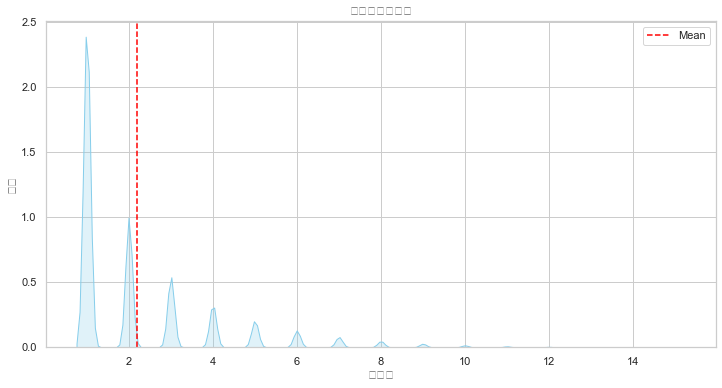

In [58]:
# 导入必要的库
import seaborn as sns
import matplotlib.pyplot as plt

# 设置图形样式
sns.set(style="whitegrid")

# 创建画布
plt.figure(figsize=(12, 6))

# 绘制KDE图
sns.kdeplot(item_comments, color='skyblue', shade=True)

# 标记均值线
plt.axvline(x=item_comments.mean(), color='red', linestyle='--', label='Mean')

# 设置图表标题和坐标轴标签
plt.xlabel('评论量')
plt.ylabel('密度')
plt.title('商品评论量分布')

# 显示图例
plt.legend()

# 显示图形
plt.show()

In [67]:
# 选取评论数量大于7的商品
selected_items = item_comments[item_comments > 7]

# 统计评论数量大于2的商品数量
num_selected_items = len(selected_items)
print("评论数量大于7的商品数量：", num_selected_items)
#4条以上:537045  5条以上：324258 6条以上：190873 7条以上：108389

评论数量大于7的商品数量： 108389


>评论数据总共有240万左右(2463545)的数据，选择2条以上的商品量为140万(1436612)，对应的商品数据就有140多万条，
用户行为数据将是商品数据的几10倍考虑到电脑的性能以及存储空间，因此选择评论量在3条以上的评论数据，有87万(876517)的数据量,但是后续对评论进行情感分析时发现数据量还是很大导致处理过程十分缓慢，因此选择评论量在7条以上，保证数据量的前提下，提高对商品的评价的情感分析。

In [68]:
# 按照商品ID分组并统计每个商品的评论数量
item_comment_counts = review.groupby('item_id')['feedback'].count()

# 筛选出评论数量大于7的商品ID列表
selected_item_ids = item_comment_counts[item_comment_counts > 7].index
# 根据筛选出的商品ID列表，从原始DataFrame中获取相关商品信息
selected_review_info = review[review['item_id'].isin(selected_item_ids)]

selected_review_info.head(10)

,item_id,rater_uid,feedback,,gmt_create
7196109,163,u6990067,很 甜 ， 个 大 。 谢谢 卖家 的 小 礼物 。,NaN,2013-06-28 10:58:01
4573298,163,u7203411,肉 香甜 ， 孩子 老人 都 喜欢 吃 ， 吃 完了 会 再 来,NaN,2013-06-27 23:59:36
4641642,163,u10604838,口感 不错 ， 个 大 ， 很 甜 哦 。 不错 ， 很 满意,NaN,2013-06-28 19:14:15
703263,163,u9260044,很 好吃 ， 我 觉得 买 枣 都 可以 在 这家 买 了 ！,NaN,2013-07-09 13:11:03
5199561,163,u1684848,红枣 很 好吃 很 甜 ， 很 香 ， 很 好吃 服务 态度 也 很 好,NaN,2013-07-01 09:36:35
6735543,163,u8741365,不好意思 ， 出差 了 几 天 ， 昨天 才 回来 ， 同事 帮 签收 的 ， 这 红枣 真...,NaN,2013-06-29 09:13:13
4475120,163,u13180153,大枣 很 大 颗 很 甜 ， 家人 都 很 喜欢 吃 ， 吃 完了 再 来 买,NaN,2013-06-27 10:30:45
3419936,163,u3435601,实在 不好意思 ， 评价 晚 了 ， 大枣 都 吃 完了 ， 哈哈 很 好 ， 还 会 ...,NaN,2013-06-27 08:55:07
8376678,183,u6062783,不是说 是 均 码 么 长 了 很 多 呢,NaN,2013-08-07 12:15:21
9387980,183,u12885089,跟 想象 当中 的 一样 ， 非常 满意 . . ！,NaN,2013-06-14 09:20:24


In [69]:
selected_review_info.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 981810 entries, 7196109 to 7492753
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   item_id     981810 non-null  int64 
 1   rater_uid   981810 non-null  object
 2   feedback    981810 non-null  object
 3               5 non-null       object
 4   gmt_create  981810 non-null  object
dtypes: int64(1), object(4)
memory usage: 44.9+ MB


问题：数据框消耗的内存量约为44.9MB，存在索引不规范（从7196109 开始），存在空白列

## 1.2 截取的评论数据规范化 <a class="anchor" id="section1_2"></a>

>截取后的数据存在有1列完全空白，用户id为：“u+数字”的形式，对后面的查询以及统计不方便，考虑去掉数字前面的u，该数据集对时间规范意义不大，但是为了规范还是增加一列规范后（年月日）的时间列。

### 1.2.1 去掉空白列

In [70]:
# 删除包含空白值的列
data_1 = selected_review_info.drop(selected_review_info.columns[3], axis=1)
# 显示处理后的DataFrame
data_1.head()

,item_id,rater_uid,feedback,gmt_create
7196109,163,u6990067,很 甜 ， 个 大 。 谢谢 卖家 的 小 礼物 。,2013-06-28 10:58:01
4573298,163,u7203411,肉 香甜 ， 孩子 老人 都 喜欢 吃 ， 吃 完了 会 再 来,2013-06-27 23:59:36
4641642,163,u10604838,口感 不错 ， 个 大 ， 很 甜 哦 。 不错 ， 很 满意,2013-06-28 19:14:15
703263,163,u9260044,很 好吃 ， 我 觉得 买 枣 都 可以 在 这家 买 了 ！,2013-07-09 13:11:03
5199561,163,u1684848,红枣 很 好吃 很 甜 ， 很 香 ， 很 好吃 服务 态度 也 很 好,2013-07-01 09:36:35


In [71]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 981810 entries, 7196109 to 7492753
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   item_id     981810 non-null  int64 
 1   rater_uid   981810 non-null  object
 2   feedback    981810 non-null  object
 3   gmt_create  981810 non-null  object
dtypes: int64(1), object(3)
memory usage: 37.5+ MB


删除空白列后，减少了内存的消耗

### 1.2.2 用户id规范

In [72]:
#使得页面统计和处理更方便
# 删除rater_uid字段中的'u'
data_1['rater_uid'] = data_1['rater_uid'].str.replace('u', '')

# 显示处理后的DataFrame
data_1.head()

,item_id,rater_uid,feedback,gmt_create
7196109,163,6990067,很 甜 ， 个 大 。 谢谢 卖家 的 小 礼物 。,2013-06-28 10:58:01
4573298,163,7203411,肉 香甜 ， 孩子 老人 都 喜欢 吃 ， 吃 完了 会 再 来,2013-06-27 23:59:36
4641642,163,10604838,口感 不错 ， 个 大 ， 很 甜 哦 。 不错 ， 很 满意,2013-06-28 19:14:15
703263,163,9260044,很 好吃 ， 我 觉得 买 枣 都 可以 在 这家 买 了 ！,2013-07-09 13:11:03
5199561,163,1684848,红枣 很 好吃 很 甜 ， 很 香 ， 很 好吃 服务 态度 也 很 好,2013-07-01 09:36:35


### 1.2.3 规范索引列

In [73]:
data_1.reset_index(drop=True, inplace=True)
data_1.head()

,item_id,rater_uid,feedback,gmt_create
0,163,6990067,很 甜 ， 个 大 。 谢谢 卖家 的 小 礼物 。,2013-06-28 10:58:01
1,163,7203411,肉 香甜 ， 孩子 老人 都 喜欢 吃 ， 吃 完了 会 再 来,2013-06-27 23:59:36
2,163,10604838,口感 不错 ， 个 大 ， 很 甜 哦 。 不错 ， 很 满意,2013-06-28 19:14:15
3,163,9260044,很 好吃 ， 我 觉得 买 枣 都 可以 在 这家 买 了 ！,2013-07-09 13:11:03
4,163,1684848,红枣 很 好吃 很 甜 ， 很 香 ， 很 好吃 服务 态度 也 很 好,2013-07-01 09:36:35


In [74]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981810 entries, 0 to 981809
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   item_id     981810 non-null  int64 
 1   rater_uid   981810 non-null  object
 2   feedback    981810 non-null  object
 3   gmt_create  981810 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.0+ MB


索引成功修改为 0 到 981809 一共981810条数据

### 1.2.4 规范时间戳

In [75]:
import pandas as pd

# 将gmt_create字段转换为日期时间类型，并提取年月日部分
data_1['create_at'] = pd.to_datetime(data_1['gmt_create']).dt.strftime('%Y-%m-%d')

# 显示处理后的DataFrame
data_1.head()

,item_id,rater_uid,feedback,gmt_create,create_at
0,163,6990067,很 甜 ， 个 大 。 谢谢 卖家 的 小 礼物 。,2013-06-28 10:58:01,2013-06-28
1,163,7203411,肉 香甜 ， 孩子 老人 都 喜欢 吃 ， 吃 完了 会 再 来,2013-06-27 23:59:36,2013-06-27
2,163,10604838,口感 不错 ， 个 大 ， 很 甜 哦 。 不错 ， 很 满意,2013-06-28 19:14:15,2013-06-28
3,163,9260044,很 好吃 ， 我 觉得 买 枣 都 可以 在 这家 买 了 ！,2013-07-09 13:11:03,2013-07-09
4,163,1684848,红枣 很 好吃 很 甜 ， 很 香 ， 很 好吃 服务 态度 也 很 好,2013-07-01 09:36:35,2013-07-01


In [76]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981810 entries, 0 to 981809
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   item_id     981810 non-null  int64 
 1   rater_uid   981810 non-null  object
 2   feedback    981810 non-null  object
 3   gmt_create  981810 non-null  object
 4   create_at   981810 non-null  object
dtypes: int64(1), object(4)
memory usage: 37.5+ MB


## 1.3 对商品评论数据的情感分析  <a class="anchor" id="section1_3"></a>

In [77]:
import pandas as pd  # 数据分析库
from textblob import TextBlob  # 英文情感分析库
import matplotlib.pyplot as plt  # 画图
from wordcloud import WordCloud  # 绘制词云图
from wordcloud import ImageColorGenerator
from PIL import Image
import numpy as np

### 1.3.1 对评论情感打分

In [78]:
#打分情感分析
#情感分析的结果是一个小数，越接近1，说明越偏向积极；越接近0，说明越偏向消极。
from snownlp import SnowNLP

score_list = []  # 情感评分值
tag_list = []  # 打标分类结果
for com in data_1['feedback']:
    tag = ''
    judge = SnowNLP(str(com))
    sentiment_score = judge.sentiments
    score_list.append(sentiment_score)
    if sentiment_score >= 0.75:
        tag = "好评"
    elif sentiment_score >= 0.5:
        tag = "一般"
    elif sentiment_score >= 0.25:
        tag = "较差"
    else:
        tag = "差评"
    tag_list.append(tag)
data_1['score'] = score_list
data_1['Result'] = tag_list

### 1.3.2 总体评论情感分析

In [79]:
data_1.groupby(by=['Result']).count()['feedback']  # 分组统计情感分析结果

Result
一般     90905
好评    693327
差评    132746
较差     64832
Name: feedback, dtype: int64

### 1.3.3 可视化结果

好评    693327
差评    132746
一般     90905
较差     64832
Name: Result, dtype: int64


Text(0.5, 1.0, '关于总体评论数据的情感分布')

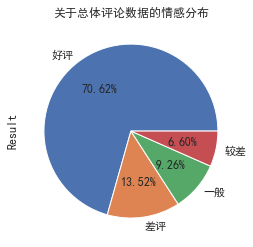

In [80]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
grp = data_1['Result'].value_counts()
print(grp)
grp.plot.pie(y='Result', autopct='%.2f%%')  # 画饼图
plt.title('关于总体评论数据的情感分布')

In [81]:
data_1['score'].mean() #接近1，表明大部分的评论是积极的

0.7684981642509522

In [82]:
data_1.head()

,item_id,rater_uid,feedback,gmt_create,create_at,score,Result
0,163,6990067,很 甜 ， 个 大 。 谢谢 卖家 的 小 礼物 。,2013-06-28 10:58:01,2013-06-28,0.950070,好评
1,163,7203411,肉 香甜 ， 孩子 老人 都 喜欢 吃 ， 吃 完了 会 再 来,2013-06-27 23:59:36,2013-06-27,0.977025,好评
2,163,10604838,口感 不错 ， 个 大 ， 很 甜 哦 。 不错 ， 很 满意,2013-06-28 19:14:15,2013-06-28,0.999531,好评
3,163,9260044,很 好吃 ， 我 觉得 买 枣 都 可以 在 这家 买 了 ！,2013-07-09 13:11:03,2013-07-09,0.848073,好评
4,163,1684848,红枣 很 好吃 很 甜 ， 很 香 ， 很 好吃 服务 态度 也 很 好,2013-07-01 09:36:35,2013-07-01,0.997111,好评


### 1.3.4 对情感分类

In [83]:
import pandas as pd

# 定义分类区间（按小数点后三位进行分段）
bins = [0, 0.199, 0.399, 0.599, 0.799, 1]
labels = ['1', '2', '3', '4', '5']

# 对Result字段进行分类
data_1['score_class'] = pd.cut(data_1['score'], bins=bins, labels=labels, include_lowest=True)

# 显示结果
data_1.head()

,item_id,rater_uid,feedback,gmt_create,create_at,score,Result,score_class
0,163,6990067,很 甜 ， 个 大 。 谢谢 卖家 的 小 礼物 。,2013-06-28 10:58:01,2013-06-28,0.950070,好评,5
1,163,7203411,肉 香甜 ， 孩子 老人 都 喜欢 吃 ， 吃 完了 会 再 来,2013-06-27 23:59:36,2013-06-27,0.977025,好评,5
2,163,10604838,口感 不错 ， 个 大 ， 很 甜 哦 。 不错 ， 很 满意,2013-06-28 19:14:15,2013-06-28,0.999531,好评,5
3,163,9260044,很 好吃 ， 我 觉得 买 枣 都 可以 在 这家 买 了 ！,2013-07-09 13:11:03,2013-07-09,0.848073,好评,5
4,163,1684848,红枣 很 好吃 很 甜 ， 很 香 ， 很 好吃 服务 态度 也 很 好,2013-07-01 09:36:35,2013-07-01,0.997111,好评,5


### 1.3.5 保存

In [84]:
#获得有情感分的评论数据
data_1.to_csv('D:\\Datas\\datas\\r_review.csv', index=False)

### 1.3.6 上传HDFS

1)新建文件夹

<img src="images/改进/评论数据/1.1 HDFS新建文件夹.png" width="800" height="500">

2)上传文件

<img src="images/改进/评论数据/1.2 上传评论数据.png" width="800" height="500">

### 1.3.7 词云图

In [86]:
#分词
import jieba
#返回生成器
def cut_word(text):
    return jieba.cut(text,cut_all=False)

    
data_1['feedback_cut'] = data_1['feedback'].apply(cut_word)
#停用词处理
def get_stopword():
    s = set()
    with open('哈工大停用词表.txt',encoding = 'UTF-8') as f:
        for line in f:
            s.add(line.strip())
    return s




def remove_stopword(words):
    return [word for word in words if word not in stopword]

stopword = get_stopword()
data_1['feedback_cut'] = data_1['feedback_cut'].apply(remove_stopword)
data_1.head()

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\LFF\AppData\Local\Temp\jieba.cache
Loading model cost 0.660 seconds.
Prefix dict has been built successfully.


,item_id,rater_uid,feedback,gmt_create,create_at,score,Result,score_class,feedback_cut
0,163,6990067,很 甜 ， 个 大 。 谢谢 卖家 的 小 礼物 。,2013-06-28 10:58:01,2013-06-28,0.950070,好评,5,"[很, , 甜, , , , 大, , , 谢谢, , 卖家, , , 小..."
1,163,7203411,肉 香甜 ， 孩子 老人 都 喜欢 吃 ， 吃 完了 会 再 来,2013-06-27 23:59:36,2013-06-27,0.977025,好评,5,"[肉, , 香甜, , , 孩子, , 老人, , 都, , 喜欢, , 吃,..."
2,163,10604838,口感 不错 ， 个 大 ， 很 甜 哦 。 不错 ， 很 满意,2013-06-28 19:14:15,2013-06-28,0.999531,好评,5,"[口感, , 不错, , , , 大, , , 很, , 甜, , , ..."
3,163,9260044,很 好吃 ， 我 觉得 买 枣 都 可以 在 这家 买 了 ！,2013-07-09 13:11:03,2013-07-09,0.848073,好评,5,"[很, , 好吃, , , , 觉得, , 买, , 枣, , 都, , ..."
4,163,1684848,红枣 很 好吃 很 甜 ， 很 香 ， 很 好吃 服务 态度 也 很 好,2013-07-01 09:36:35,2013-07-01,0.997111,好评,5,"[红枣, , 很, , 好吃, , 很, , 甜, , , 很, , 香, ..."


In [87]:
from wordcloud import WordCloud
from imageio import imread
bg_pic = imread('heart.png')

#设置词云字体
font_wc= r'C:\Windows\Fonts\msyhbd.ttc'

#生成词云
wc = WordCloud(font_path=font_wc
               ,mask=bg_pic
               ,max_words=500
               ,max_font_size=200
               ,background_color='white'
               ,colormap= 'Reds_r'
               ,scale=15.5)

(-0.5, 15871.5, 15871.5, -0.5)

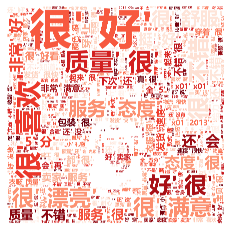

In [88]:
#生成词云 
myText=' '.join(data_1['feedback_cut'].astype(str))

wc.generate(myText)
plt.imshow(wc)
plt.axis('off')

In [ ]:
#截取数据
import pandas as pd

# 按照商品ID分组并统计每个商品的评论数量
item_comment_counts = review.groupby('item_id')['feedback'].count()
# 筛选出评论数量大于7的商品ID列表
selected_item_ids = item_comment_counts[item_comment_counts > 7].index
# 根据筛选出的商品ID列表，从原始DataFrame中获取相关商品信息
selected_review_info = review[review['item_id'].isin(selected_item_ids)]
# 删除包含空白值的列
data_1 = selected_review_info.drop(selected_review_info.columns[3], axis=1)
# 删除rater_uid字段中的'u'
data_1['rater_uid'] = data_1['rater_uid'].str.replace('u', '')
#规范索引列
data_1.reset_index(drop=True, inplace=True)
# 将gmt_create字段转换为日期时间类型，并提取年月日部分
data_1['create_at'] = pd.to_datetime(data_1['gmt_create']).dt.strftime('%Y-%m-%d')

In [ ]:
#情感打分
#情感分析的结果是一个小数，越接近1，说明越偏向积极；越接近0，说明越偏向消极。
from snownlp import SnowNLP

score_list = []  # 情感评分值
for com in data_1['feedback']:
    judge = SnowNLP(str(com))
    sentiment_score = judge.sentiments
    score_list.append(sentiment_score)
data_1['score'] = score_list